<div style="background-color:#7BAFD4;border-radius:18px;padding:22px 26px;margin-bottom:18px;">
<div style="font-family:Impact,'Arial Black',Arial,sans-serif;font-size:42px;font-weight:900;letter-spacing:2px;line-height:1;color:white;">GEOG 592</div>
<div style="font-family:Arial,Helvetica,sans-serif;font-size:22px;font-weight:700;color:#13294B;margin-top:8px;">GIS Programming</div>
<div style="font-family:Arial,Helvetica,sans-serif;font-size:16px;color:#13294B;margin-top:6px;">GeoPandas — CRS, Geometry, and Measurement</div></div>

# Measuring spatial data

Spatial measurements only make sense when we understand the coordinate system.

This module focuses on CRS, area, length, centroid, distance, and CRS transformations.


In [8]:
%pip install geopandas

Note: you may need to restart the kernel to use updated packages.


In [9]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [10]:
import geopandas as gpd
import matplotlib.pyplot as plt

In [11]:
## https://services.arcgis.com/NuWFvHYDMVmmxMeM/ArcGIS/rest/services/Chapel_Hill_Trails_WFL1/FeatureServer/15/query?where=1%3D1&outFields=*&returnGeometry=true&outSR=4326&f=geojson
parks = gpd.read_file("parks.geojson")
stops = gpd.read_file("chapel_hill_bus_stops.geojson")

## Inspect the CRS

Coordinate reference system

In [12]:
print(parks.crs)
print(stops.crs)


EPSG:4326
EPSG:4326


For area, length, and distance, an appropriate projected CRS is usually required because longitude and latitude are angular units. But let's see what happens.

In [13]:
list(parks.columns)

['FID',
 'AREA_',
 'PERIMETER',
 'PARCELS_',
 'PARCELS_ID',
 'CREATION',
 'SIZE',
 'OWNER',
 'PIN',
 'TMBL',
 'DESC_',
 'DEEDREF',
 'PLAT_BKPG',
 'NAME',
 'TYPE',
 'CATEGORY_1',
 'Acres',
 'GlobalID',
 'Acquired',
 'Year',
 'Shape__Area',
 'Shape__Length',
 'geometry']

## Calculate area

In [14]:
parks["area_sqft"] = parks.geometry.area
parks[["NAME","area_sqft"]]

/var/folders/8h/fkwb02_15hs7g69qdmc19pn80000gn/T/ipykernel_8483/3880462973.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  parks["area_sqft"] = parks.geometry.area


,NAME,area_sqft
0,Lewis' Heartleaf Preserve,0.000004
1,Cedar Grove Park (additional land),0.000005
2,Little River Regional Park,0.000003
3,Little River Regional Park,0.000051
4,Lake Orange,0.000066
...,...,...
63,Piney Mountain subdivision (Ph1 & 2),0.000005
64,,0.000026
65,New Hope Preserve,0.000001
66,Mountains to Sea Trail access,0.000005


You should notice an error and also the result. Those parks are less than 1 sq ft. So first let's reproject that data to a projection using feet as units. For NC we can use the new CRS 6543 (this looks like a fake number but we are lucky that it is an easy number to remember). The older version was also easy (2264), and it is ok to use for our purpose. But start getting used to using 6543 when working in NC.    

## Transform the CRS

In [15]:
parks_6543 = parks.to_crs(epsg=6543)
parks_6543.crs

<Projected CRS: EPSG:6543>
Name: NAD83(2011) / North Carolina (ftUS)
Axis Info [cartesian]:
- X[east]: Easting (US survey foot)
- Y[north]: Northing (US survey foot)
Area of Use:
- name: United States (USA) - North Carolina - counties of Alamance; Alexander; Alleghany; Anson; Ashe; Avery; Beaufort; Bertie; Bladen; Brunswick; Buncombe; Burke; Cabarrus; Caldwell; Camden; Carteret; Caswell; Catawba; Chatham; Cherokee; Chowan; Clay; Cleveland; Columbus; Craven; Cumberland; Currituck; Dare; Davidson; Davie; Duplin; Durham; Edgecombe; Forsyth; Franklin; Gaston; Gates; Graham; Granville; Greene; Guilford; Halifax; Harnett; Haywood; Henderson; Hertford; Hoke; Hyde; Iredell; Jackson; Johnston; Jones; Lee; Lenoir; Lincoln; Macon; Madison; Martin; McDowell; Mecklenburg; Mitchell; Montgomery; Moore; Nash; New Hanover; Northampton; Onslow; Orange; Pamlico; Pasquotank; Pender; Perquimans; Person; Pitt; Polk; Randolph; Richmond; Robeson; Rockingham; Rowan; Rutherford; Sampson; Scotland; Stanly; Stoke

## Calculate the area using the correct CRS

In [16]:
parks_6543["area_sqft"] = parks_6543.geometry.area
parks_6543[["NAME","area_sqft"]]

,NAME,area_sqft
0,Lewis' Heartleaf Preserve,4.390760e+05
1,Cedar Grove Park (additional land),5.229946e+05
2,Little River Regional Park,2.901162e+05
3,Little River Regional Park,5.430331e+06
4,Lake Orange,7.067512e+06
...,...,...
63,Piney Mountain subdivision (Ph1 & 2),5.895073e+05
64,,2.772937e+06
65,New Hope Preserve,1.132557e+05
66,Mountains to Sea Trail access,4.939799e+05


## Compare your results

In [17]:
## The GeoJSON already had a column with the area value,
##  So we can compare now if similar.  
parks_6543[["area_sqft","AREA_"]].iloc[0]
parks_6543[["area_sqft","AREA_"]].mean()


area_sqft    1.075571e+06
AREA_        1.020001e+06
dtype: float64

### Verify

Looks good for the first record. Can you think of a way to check if that is the case for all the features?

### Check the area
 Think of ways to check if the `Area_` is the same as `area_sqft` that you calculated. Use your knowledge using Pandas or R to come up with a solution




# Don't look at my answer yet. 





### Write it here in the markdown with your own words




## Then translate to code




## Don't look yet, or ask AI: there are so many ways to do it!






#
#




In [18]:
## I did it by calculating the mean absolute difference 
mean_absolute_difference = (
    parks_6543["area_sqft"] - parks_6543["AREA_"]
).abs().mean()
print(mean_absolute_difference)

58287.11127847762


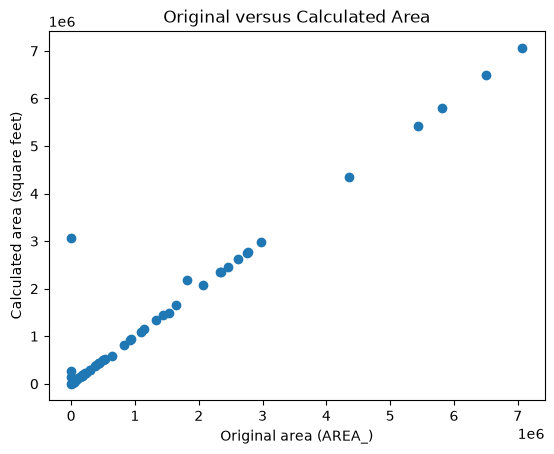

In [19]:
## ok something is wrong
## I will practice our previous modules
import matplotlib.pyplot as plt
plt.scatter(
    parks_6543["AREA_"],
    parks_6543["area_sqft"]
)

plt.xlabel("Original area (AREA_)")
plt.ylabel("Calculated area (square feet)")
plt.title("Original versus Calculated Area")

plt.show()

In [20]:
# not good
# seems like there are several "AREA_" that have 0 values
print((parks_6543["AREA_"] == 0).count())

68


So AREA_ has a lot of zeros: it's a good thing that we calculated area on our own and did not rely on the table. 

## Calculate perimeter

In [21]:
parks_6543["perimeter_ft"] = parks_6543.geometry.length
parks_6543[["NAME","perimeter_ft"]]

,NAME,perimeter_ft
0,Lewis' Heartleaf Preserve,3466.652464
1,Cedar Grove Park (additional land),3437.571477
2,Little River Regional Park,4303.444097
3,Little River Regional Park,11547.069571
4,Lake Orange,35133.595851
...,...,...
63,Piney Mountain subdivision (Ph1 & 2),5622.937309
64,,10256.433190
65,New Hope Preserve,1735.659694
66,Mountains to Sea Trail access,8802.239981


## Calculate centroids

In [22]:
parks_6543["centroid"] = parks_6543.geometry.centroid
parks_6543[["NAME","centroid"]]

,NAME,centroid
0,Lewis' Heartleaf Preserve,POINT (1951450.167 901464.41)
1,Cedar Grove Park (additional land),POINT (1960583.874 884224.223)
2,Little River Regional Park,POINT (2011226.778 883073.409)
3,Little River Regional Park,POINT (2009470.543 878432.498)
4,Lake Orange,POINT (1956683.099 875254.231)
...,...,...
63,Piney Mountain subdivision (Ph1 & 2),POINT (1999312.701 819426.829)
64,,POINT (1970384.455 805592.005)
65,New Hope Preserve,POINT (1999953.315 811274.862)
66,Mountains to Sea Trail access,POINT (1925307.442 801974.706)


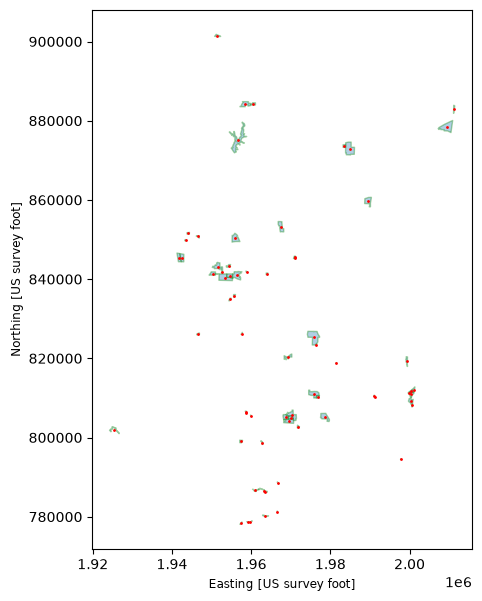

In [23]:
centroids = parks_6543.set_geometry("centroid").copy()
fig, ax = plt.subplots(figsize=(7,7))
parks_6543.plot(ax=ax, alpha=0.35, edgecolor="green")
centroids.plot(ax=ax, markersize=1, c="red")
plt.show()

## Distance from every stop to one park

In [24]:
#first remember to change the CRS 
stops_6543 = stops.to_crs(epsg=6543)
park_1 = parks_6543.geometry.iloc[0]
stops_6543["distance_to_park1"] = stops_6543.geometry.distance(park_1)
#this distance is calculated for each point to the boundary of the polygon (not the centroid)
print(park_1)
stops_6543.sort_values("distance_to_park1")[["NAME","distance_to_park1"]]

POLYGON ((1952279.134318487 901345.185251576, 1952282.0198126703 901307.016028428, 1952284.7622624605 901270.7385342156, 1950757.4060661374 901302.2364838661, 1951169.8193628883 901816.3461372433, 1952279.134318487 901345.185251576))


,NAME,distance_to_park1
0,Lewis' Heartleaf Preserve,0.000000
39,Cedar Grove Park,17346.692601
1,Cedar Grove Park (additional land),18573.050123
4,Lake Orange,22326.697130
38,Northeast Park,41277.651838
...,...,...
30,Lake Woods subdivision,120681.673991
42,Orchard S/D,121277.503643
31,Quailview subdivision,122564.092732
32,Giera & Olson subdivision,122695.006613


AttributeError: _GeoPandasPolyCollection.set() got an unexpected keyword argument 'c'

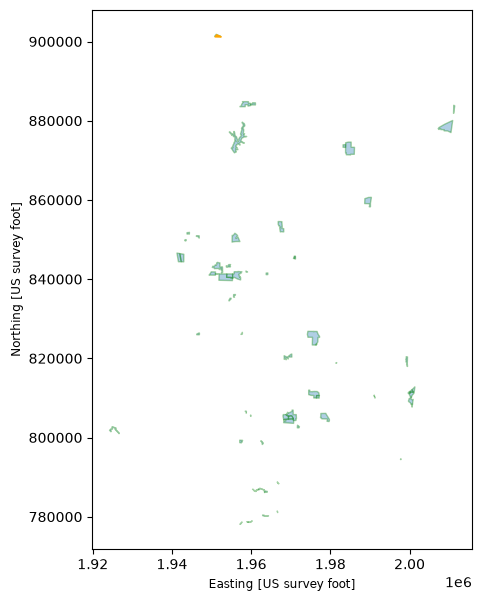

In [25]:
## the nearest stop is pretty far 52910.608473 feet, so around 10 miles :(
nearStop = stops_6543[stops_6543["NAME"]=='Cornelius St (US 70) at Rainey Rd']
fig, ax = plt.subplots(figsize=(7,7))
parks_6543.plot(ax=ax, alpha=0.35, edgecolor="green")
parks_6543.iloc[[0]].plot(ax=ax, edgecolor="orange", color="orange")
stops_6543.plot(ax=ax, markersize=1, c="cyan")
nearStop.plot(ax=ax, markersize=10, c="red")
plt.show()

It is important to remember that the distance is calculated from the perimeter of the polygon, not from the centroid. The previous example is not obvious, but hopefully this example makes it more clear. 

In [ ]:
## create some simple geometries 

from shapely.geometry import Polygon, Point
from matplotlib.lines import Line2D

polygons = [
    Polygon([(2, 2), (6, 2), (6, 5), (2, 5)]),
    Polygon([(9, 2), (13, 2), (13, 5), (9, 5)]),
    Polygon([(2, 9), (6, 9), (6, 13), (2, 13)]),
    Polygon([(9, 9), (13, 9), (13, 13), (9, 13)])
]

example_parks = gpd.GeoDataFrame(
    {"name": ["A", "B", "C", "D"]},
    geometry=polygons,
    crs="EPSG:3857"
)

example_city_center = Point(10, 6)


In [ ]:
example_parks["distance"] = (
    example_parks.geometry.distance(example_city_center)
)

example_parks[["name", "distance"]]

In [ ]:
# calculate distance from centroid

example_parks["centroid_distance"] = (
    example_parks.geometry.centroid.distance(example_city_center)
)

example_parks[
    ["name", "distance", "centroid_distance"]
]

In [ ]:
# creating lines to represent the shortest path 
distance_lines = example_parks.geometry.shortest_line(
    example_city_center
)

# creating the centroids
centroids = example_parks.geometry.centroid

print(distance_lines)

In [ ]:
## FIGURE created using AI

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(8, 8))

# Example parks
example_parks.plot(
    ax=ax,
    facecolor="lightgray",
    edgecolor="black",
    zorder=1
)

# Actual polygon distance
distance_lines.plot(
    ax=ax,
    color="blue",
    linewidth=3,
    zorder=2
)

# Distance from centroid
centroid_lines.plot(
    ax=ax,
    color="orange",
    linestyle="--",
    linewidth=2,
    zorder=3
)

# Centroids
centroids.plot(
    ax=ax,
    color="orange",
    markersize=40,
    zorder=4
)

# City center -- draw last and on top
gpd.GeoSeries(
    [example_city_center],
    crs=example_parks.crs
).plot(
    ax=ax,
    color="red",
    edgecolor="black",
    markersize=100,
    zorder=5
)

# Legend
legend_items = [
    Patch(
        facecolor="lightgray",
        edgecolor="black",
        label="Example Parks"
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="none",
        markerfacecolor="red",
        markeredgecolor="black",
        markersize=9,
        label="City Center"
    ),
    Line2D(
        [0], [0],
        color="blue",
        linewidth=3,
        label="Distance from polygon"
    ),
    Line2D(
        [0], [0],
        color="orange",
        linestyle="--",
        linewidth=2,
        label="Distance from centroid"
    )
]

ax.legend(handles=legend_items)

ax.set_xlim(0, 19)
ax.set_ylim(0, 16)
ax.set_aspect("equal")

ax.set_title("Polygon Distance vs. Centroid Distance")

plt.show()

## Practice

- inspect the CRS
- calculate area and perimeter
- calculate centroids
- transform the layer to EPSG:6543
- explain why geographic coordinates are not ideal for area
- calculate distance from every stop to one park
- sort the stops from nearest to farthest


## What to remember

```python
gdf.crs
gdf.to_crs(...)
gdf.geometry.area
gdf.geometry.length
gdf.geometry.centroid
gdf.geometry.distance(...)
```

The key GIS principle is:

> **Geometry calculations depend on the CRS and its units.**


often we get data sets that give you values of area that are completely messed up- look at the data, plot it, project to your local proection